In [1]:
from pathlib import Path
import pandas as pd

from constants import (
    init_paths,
    result_path,
)
from pca import (
    run_monthly_analysis,
    load_dispersion_data,
    plot_eta_vr,
    plot_intday_news,
    plot_intday_news_tight,
    plot_sbeta_by_pcbeta2,
    plot_implied_pattern,
)
init_paths()


In [2]:
ym_list = pd.date_range("2006-01", "2025-12", freq="MS").strftime("%Y-%m").tolist()
rp = Path(result_path)

# Recompute the monthly outputs only when the cached result files are missing.
if not (rp / "monthly_eta_vr.csv").exists() or not (rp / "monthly_disp.csv").exists():
    run_monthly_analysis(ym_list=ym_list)
else:
    print("Results exist, skipping run_monthly_analysis")

disp_data = load_dispersion_data()

monthly_disp = pd.read_csv(rp / "monthly_disp.csv")
no_local_months = monthly_disp.loc[monthly_disp["nCluster"] == 0, "YM"]
no_local_months = pd.to_datetime(no_local_months.astype(str), format="%Y%m").dt.strftime("%Y-%m")
print("Months with no identified local factors:", no_local_months.tolist())

Results exist, skipping run_monthly_analysis
Months with no identified local factors: []


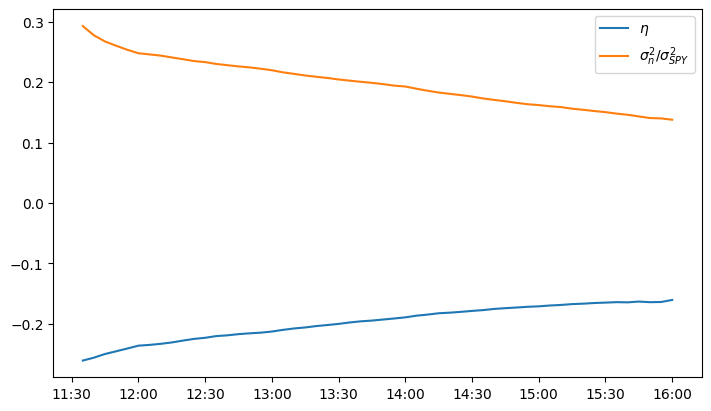

In [3]:
plot_eta_vr(disp_data)

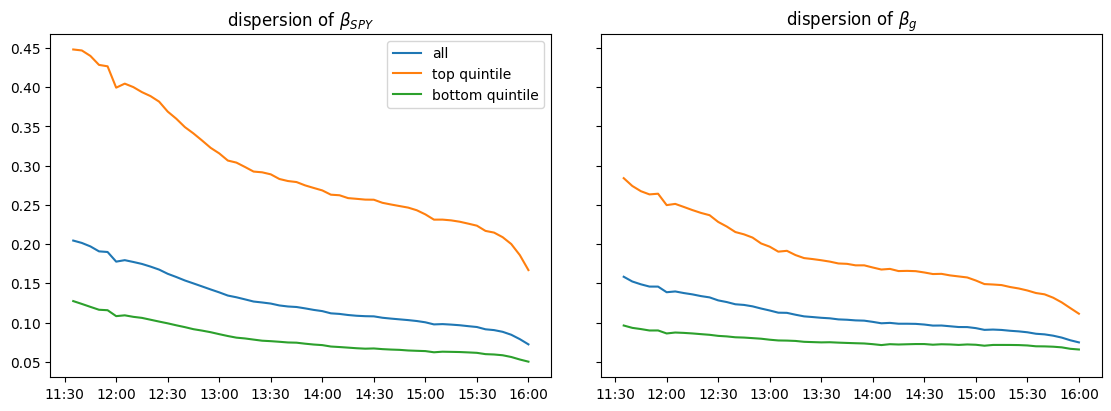

In [4]:
plot_intday_news(disp_data)

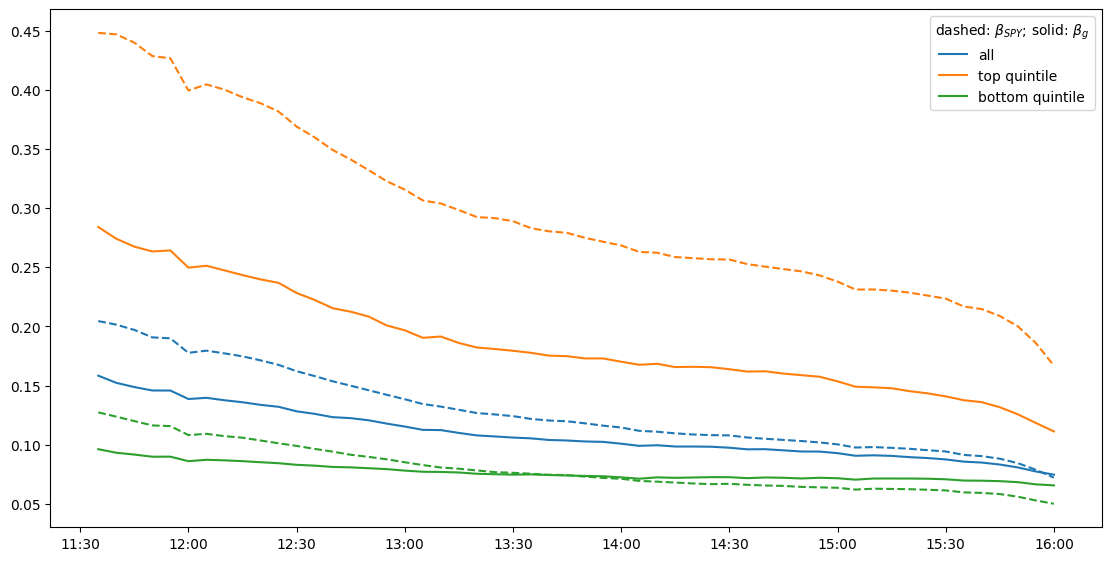

In [5]:
plot_intday_news_tight(disp_data)

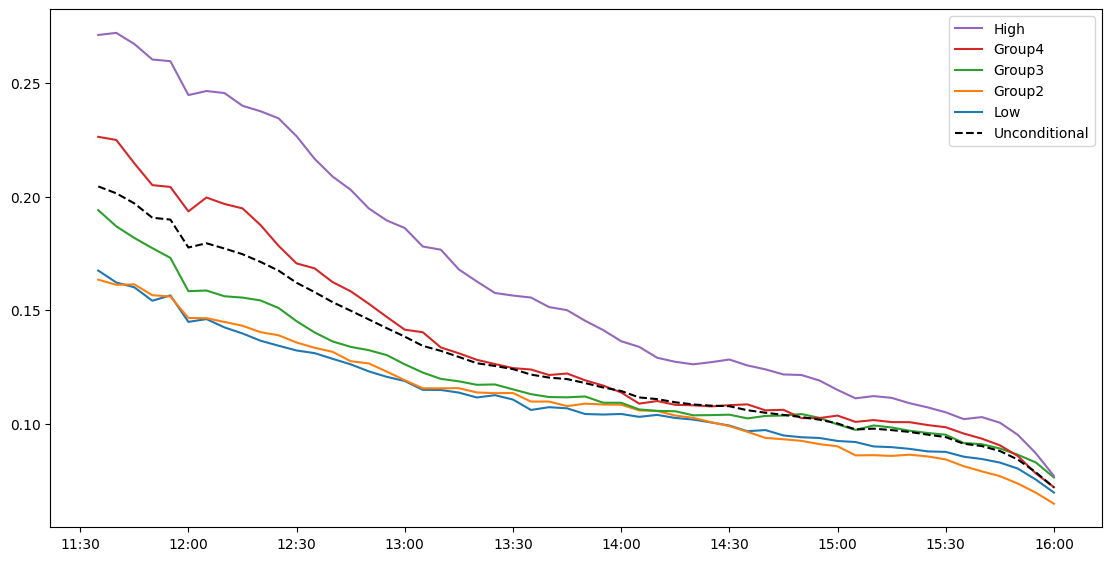

In [6]:
plot_sbeta_by_pcbeta2(disp_data)

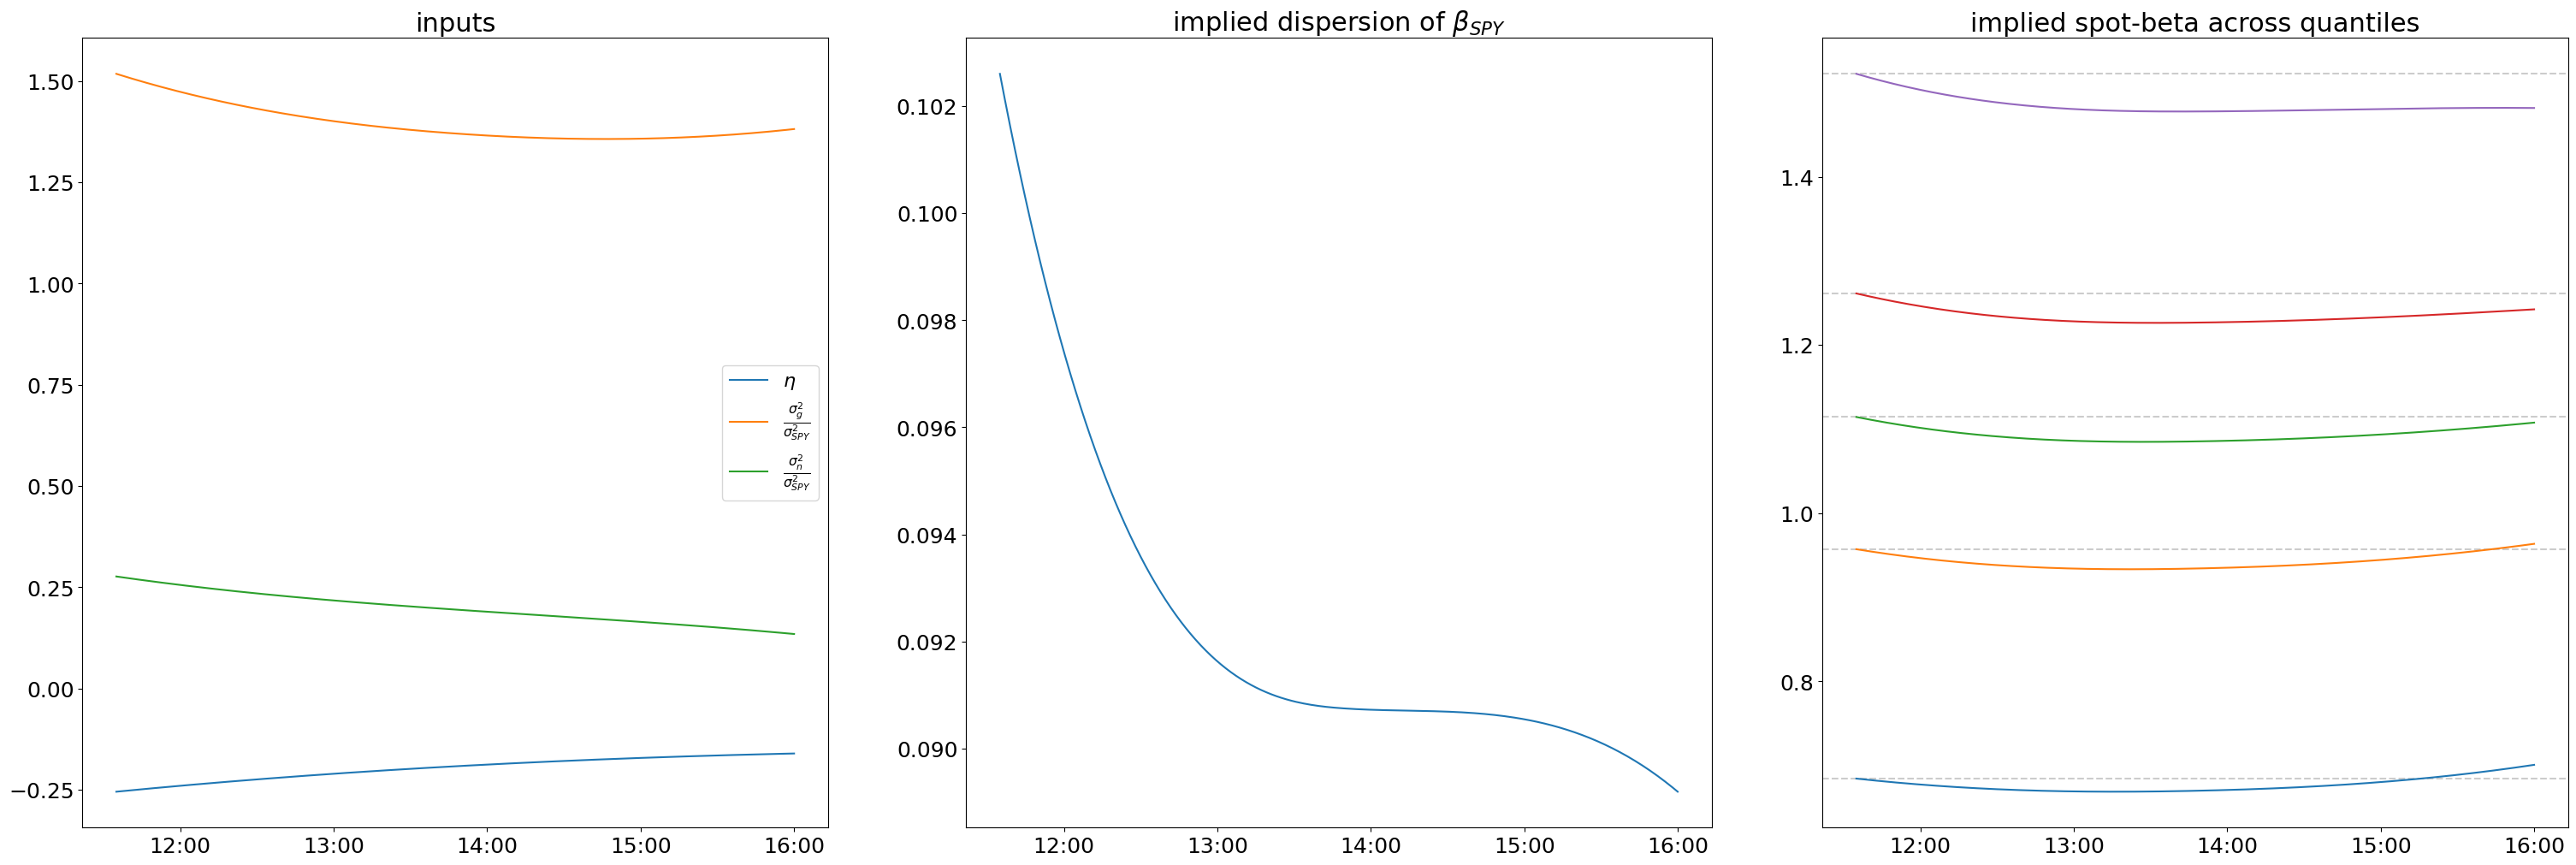

In [7]:
plot_implied_pattern(disp_data)